## Assignment 1: Data Prep & Simple Model Fit

1. Import `income.csv` and run your data prep function on it
2. Fit a logistic regression to predict income class using just the `age` and `hoursperweek` variables as features.
3. Take some time to interpet the impact of age on the probability someone makes over 50k. What is the impact of a one year increase in age?
4. Plot age vs. predicted probability.

In [1]:
import pandas as pd
import numpy as np

income = pd.read_csv("../Data/income.csv")

income.head()

,age,JobType,EdType,maritalstatus,occupation,relationship,race,gender,capitalgain,capitalloss,hoursperweek,nativecountry,SalStat
0,45,Private,HS-grad,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,28,United-States,"less than or equal to 50,000"
1,24,Federal-gov,HS-grad,Never-married,Armed-Forces,Own-child,White,Male,0,0,40,United-States,"less than or equal to 50,000"
2,44,Private,Some-college,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,"greater than 50,000"
3,27,Private,9th,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,Mexico,"less than or equal to 50,000"
4,20,Private,Some-college,Never-married,Sales,Not-in-family,White,Male,0,0,35,United-States,"less than or equal to 50,000"


In [2]:
def income_model_prep(data):
    from sklearn.model_selection import train_test_split
    data = pd.get_dummies(
        data.assign(
            target = np.where(data["SalStat"] == " less than or equal to 50,000", 0, 1),
            nativecountry = data["nativecountry"].replace({" Holand-Netherlands": " Germany"}),
            occupation = data["occupation"].replace({" Armed-Forces": " ?"}),
            JobType = data["JobType"].replace({" Never-worked": " Without-pay"}),
        ).drop("SalStat", axis=1), 
        drop_first=True
    )
    X = data.drop("target", axis=1)
    y = data["target"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = income_model_prep(income)

In [3]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

lr = logreg.fit(X_train[["age", "hoursperweek"]], y_train)

print(f"Train Accuracy: {lr.score(X_train[['age', 'hoursperweek']], y_train)}")
print(f"Test Accuracy: {lr.score(X_test[['age', 'hoursperweek']], y_test)}")

Train Accuracy: 0.7533812837151121
Test Accuracy: 0.7570356472795498


In [4]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, lr.predict(X_test[['age', 'hoursperweek']]))

array([[4687,  194],
       [1360,  155]], dtype=int64)

In [5]:
lr.coef_

array([[0.04276938, 0.04874468]])

In [6]:
np.exp(lr.coef_)

array([[1.04369717, 1.04995224]])

1 unit increase in age, 1,049 icrease in odds, making >50000

<Axes: xlabel='age'>

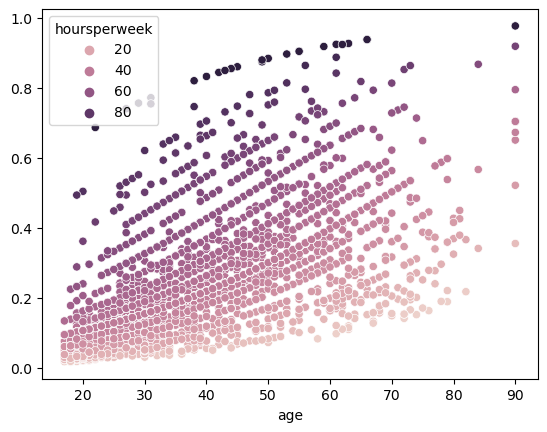

In [7]:
import seaborn as sns

sns.scatterplot(
    x=X_test["age"], 
    y=lr.predict_proba(X_test[['age', 'hoursperweek']])[:, 1],
    hue=X_test["hoursperweek"]
)

## Assignment 2: Model Tuning

1. Fit a Regression using all available features - remove features if it appears there is overfitting.

2. Tune the regularization paramters once you've decided on a set of features.

In [7]:
logreg = LogisticRegression(max_iter=5000)
lr = logreg.fit(X_train.values, y_train)

print(f"Train Accuracy: {lr.score(X_train.values, y_train)}")
print(f"Test Accuracy: {lr.score(X_test.values, y_test)}")

Train Accuracy: 0.8501289969509812
Test Accuracy: 0.8544402751719825


In [8]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [11]:
from sklearn.model_selection import GridSearchCV

parameters = [
    {
        "penalty": ["l1", "l2"],
        "C": np.linspace(0.1, 2, 10)
    },
    {
        "penalty": ["elasticnet"],
        "C": np.linspace(0.1, 2, 10),
        "l1_ratio": np.linspace(0, 1, 6)
    }
]

gridsearch = GridSearchCV(LogisticRegression(solver="saga", max_iter=1000), parameters,     cv=5,
    n_jobs=-1)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'C': 0.5222222222222223, 'l1_ratio': 0.8, 'penalty': 'elasticnet'}

In [12]:
gridsearch.best_params_

{'C': 0.5222222222222223, 'l1_ratio': 0.8, 'penalty': 'elasticnet'}

In [9]:
logreg = LogisticRegression(C=.52, penalty='elasticnet', l1_ratio=0.8, solver="saga", max_iter=1000)

lr = logreg.fit(X_train_std, y_train)

print(f"Train Accuracy: {lr.score(X_train_std, y_train)}")
print(f"Test Accuracy: {lr.score(X_test_std, y_test)}")

Train Accuracy: 0.8520444062231256
Test Accuracy: 0.8567854909318324


Modelio tikslumas treniravimo duomenyse yra 0.852 (85.2 %), o testavimo duomenyse – 0.857 (85.7 %). 

Kadangi treniravimo ir testavimo rezultatai yra labai panašūs, modelis greičiausiai **neperfitina** ir gerai **generalizuoja naujus duomenis**.

In [16]:
confusion_matrix(lr.predict(X_test_std ), y_test)

array([[4542,  577],
       [ 339,  938]], dtype=int64)

Confusion matrix rodo, kaip modelis klasifikuoja dvi klases.

- **True Negative (4542)** – modelis teisingai prognozavo neigiamą klasę.
- **False Positive (577)** – modelis klaidingai prognozavo teigiamą klasę.
- **False Negative (339)** – modelis neaptiko tikros teigiamos klasės.
- **True Positive (938)** – modelis teisingai prognozavo teigiamą klasę.

Didžioji dalis prognozių yra teisingos, tačiau modelis vis dar padaro klaidų tiek **false positives**, tiek **false negatives**.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = lr.predict(X_test_std)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8567854909318324
Precision: 0.7345340642129993
Recall: 0.6191419141914192
F1-score: 0.6719197707736391
Confusion Matrix:
[[4542  339]
 [ 577  938]]


Modelio **accuracy** yra 0.857 (85.7 %), todėl dauguma prognozių yra teisingos.

**Precision = 0.735** reiškia, kad apie 73.5 % prognozuotų teigiamų atvejų yra teisingi.

**Recall = 0.619** rodo, kad modelis aptinka apie 61.9 % visų tikrų teigiamų atvejų.

**F1-score = 0.672** yra precision ir recall balansas, rodantis vidutinį modelio gebėjimą aptikti teigiamą klasę.

Confusion matrix rodo, kad modelis teisingai klasifikavo daug neigiamų atvejų (4542), tačiau dalį teigiamų atvejų praleido (577 false negatives).

# Multiclass Logistic Regression

1. Fit a multiclass logistic regression on the data below
2. Create a confusion matrix and report accuracy score for the test data.

In [10]:
credit_df = pd.read_csv("../Data/credit_train_clean.csv").drop(["Name", "SSN"], axis=1)

credit_df.head()

,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [12]:
credit_df.dtypes

ID                            int64
Customer_ID                   int64
Month                         int64
Age                         float64
Occupation                   object
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Type_of_Loan                 object
Delay_from_due_date         float64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Age          float64
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Payment_Behaviour            object
Monthly_Balance             float64
Credit_Score                 object
dtype: object

In [11]:
credit_df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

features = [
    "Age",
    "Month",
    "Annual_Income",
    "Num_Bank_Accounts",
    "Changed_Credit_Limit",
    "Num_Credit_Card",
    "Credit_History_Age", 
    "Payment_of_Min_Amount", 
    "Monthly_Balance", 
    "Payment_Behaviour",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Mix",
    "Total_EMI_per_month"
]

X = pd.get_dummies(credit_df[features], dtype="int", drop_first=True)
y = credit_df["Credit_Score"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [14]:
X_test.head()

,Age,Month,Annual_Income,Num_Bank_Accounts,Changed_Credit_Limit,Num_Credit_Card,Credit_History_Age,Monthly_Balance,Num_Credit_Inquiries,Outstanding_Debt,Total_EMI_per_month,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Credit_Mix_Good,Credit_Mix_Standard
65740,42.0,5,39849.72,9.0,9.12,8.0,73.0,384.540284,14.0,2533.64,96.604035,0,1,0,0,0,1,0,0,1
11139,50.0,4,16558.12,3.0,3.57,7.0,232.0,247.055794,1.0,15.43,35.387555,1,0,0,0,0,0,1,1,0
99196,35.0,5,96047.22,3.0,4.75,3.0,212.0,742.619597,4.0,1366.21,49.656727,1,0,1,0,0,0,0,1,0
33120,26.0,1,32904.13,2.0,7.43,7.0,189.0,326.879129,2.0,781.45,46.033182,1,0,0,1,0,0,0,1,0
41199,27.0,8,32428.98,6.0,21.88,5.0,132.0,329.887223,11.0,4903.14,109.273296,0,0,0,0,0,1,0,0,0


In [17]:
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))

0.612375
0.6066


In [22]:
lr.classes_

array(['Good', 'Poor', 'Standard'], dtype=object)

In [28]:
y_train.value_counts()

Credit_Score
Standard    42587
Poor        23183
Good        14230
Name: count, dtype: int64

In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, lr.predict(X_train))

array([[ 3287,   254, 10689],
       [  721, 11672, 10790],
       [ 2215,  6341, 34031]], dtype=int64)

| Actual \ Predicted | Good | Poor | Standard |
|--------------------|------|------|----------|
| Good               | 3287 | 254  | 10689    |
| Poor               | 721  | 11672| 10790    |
| Standard           | 2215 | 6341 | 34031    |

Confusion matrix rodo modelio prognozes trims klasėms: Good, Poor ir Standard.

Good klasėje modelis teisingai atpažino 3287 atvejus, tačiau daug jų (10689) klaidingai priskyrė Standard klasei.

Poor klasėje modelis teisingai klasifikavo 11672 atvejus, bet nemažą dalį (10790) priskyrė Standard klasei.

Standard klasę modelis atpažįsta geriausiai – teisingai klasifikuoti 34031 atvejai, nors dalis jų priskirti Good (2215) arba Poor (6341).

Bendra tendencija rodo, kad modelis dažnai prognozuoja Standard klasę ir sunkiau atskiria Good bei Poor nuo Standard.

In [32]:
y_test.value_counts()

Credit_Score
Standard    10587
Poor         5815
Good         3598
Name: count, dtype: int64

In [30]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, lr.predict(X_test))

array([[ 837,   71, 2690],
       [ 180, 2812, 2823],
       [ 563, 1541, 8483]], dtype=int64)

| Actual \ Predicted | Good | Poor | Standard |
|--------------------|------|------|----------|
| Good               | 837  | 71   | 2690     |
| Poor               | 180  | 2812 | 2823     |
| Standard           | 563  | 1541 | 8483     |


Confusion matrix rodo modelio prognozių pasiskirstymą testavimo duomenyse trijose klasėse: Good, Poor ir Standard.

Good klasėje modelis teisingai atpažino 837 atvejus, tačiau didelę dalį jų (2690) klaidingai priskyrė Standard klasei.

Poor klasėje modelis teisingai klasifikavo 2812 atvejų, tačiau nemažą dalį (2823) taip pat priskyrė Standard klasei.

Standard klasę modelis atpažįsta geriausiai – teisingai klasifikuoti 8483 atvejai, nors dalis jų klaidingai priskirti Good (563) arba Poor (1541).

Rezultatai rodo, kad modelis dažniausiai prognozuoja Standard klasę ir sunkiau atskiria Good bei Poor klases nuo Standard.


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average=None))
print("Recall:", recall_score(y_test, y_pred, average=None))
print("F1-score:", f1_score(y_test, y_pred, average=None))

print(classification_report(y_test, y_pred))

Accuracy: 0.6066
Precision: [0.52974684 0.63562387 0.60610174]
Recall: [0.23262924 0.48357696 0.8012657 ]
F1-score: [0.32329085 0.54927239 0.69015173]
              precision    recall  f1-score   support

        Good       0.53      0.23      0.32      3598
        Poor       0.64      0.48      0.55      5815
    Standard       0.61      0.80      0.69     10587

    accuracy                           0.61     20000
   macro avg       0.59      0.51      0.52     20000
weighted avg       0.60      0.61      0.58     20000



Modelio **accuracy yra 0.6066**, todėl apie 60.7 % visų prognozių testavimo duomenyse yra teisingos.

**Good klasė** turi precision 0.53, tačiau recall tik 0.23. Tai reiškia, kad modelis randa tik nedidelę dalį tikrų Good atvejų ir dažnai jų neatpažįsta.

**Poor klasė** turi precision 0.64 ir recall 0.48, todėl modelis šią klasę atpažįsta vidutiniškai – maždaug pusė tikrų Poor atvejų aptinkami.

**Standard klasė** turi precision 0.61 ir labai aukštą recall 0.80. Tai rodo, kad modelis geriausiai atpažįsta Standard klasę ir daugumą šios klasės atvejų klasifikuoja teisingai.

**F1-score** taip pat rodo, kad modelis geriausiai veikia su Standard klase (0.69), prasčiau su Poor (0.55) ir silpniausiai su Good (0.32).

Bendrai rezultatai rodo, kad modelis dažniausiai linkęs prognozuoti Standard klasę ir sunkiau atskiria Good bei Poor klases.

In [18]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators = 10, random_state = 42)
rf.fit(X_train, y_train)

rf.score(X_test, y_test)

0.7881